<a href="https://colab.research.google.com/github/braltoids0089/AGRO-BIOTECHNOLOGY/blob/main/L1_SmartMatrix_Mechanistic%2BMapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartMatrix R&D Accelerator · Notebook 1 of 3 · **v2**
## Layer 1 — Mechanistic mapping: can the stack recover *what drives* the matrix phenotype?

**Question (Layer 1, supports H1).** Which decision and context variables carry most of the variance in texture, off-flavour and functional-metabolite outcomes, and do targeted perturbations confirm the proposed mechanisms?

### v1 record (pre-registered, kept unchanged)
| Check | v1 value | v1 result |
|---|---|---|
| Kinetic parameters recoverable from telemetry (Spearman ≥ 0.7) | 0.77 | PASS |
| Driver ranking agrees with true sensitivity (median ρ ≥ 0.7) | 0.60 | FAIL |
| Dominant true driver identified (≥ 4 of 5 outcomes) | 3/5 | FAIL |
| Perturbation rejects no-path genes and confirms a decarboxylase | `hdcA` confirmed; `gadB`, `bg01` rejected | PASS |
| KG predictions agree in direction with measured phenotypes | 4/4 | PASS |

The v1 misses were systematic: texture was credited to solids instead of sucrose, and off-flavour to the faba:pea ratio instead of inoculum. Sucrose and inoculum act mainly through **interactions with single genes** (sucrose × `dsrA` → dextran; inoculum × ADH genes → hexanal removal).

### What changed in v2
| Change | Reason |
|---|---|
| 8 substrate lots (L1–L4 identical to v1) | lot effects were unidentifiable with 4 |
| 6 design points in triplicate (was 4) | v1 noise estimates had only 8 degrees of freedom |
| Ground-truth indices averaged over strains **and** lots | same population the experiment samples |
| New check: are missed drivers interaction-dominated? | tests the v1 explanation instead of asserting it |
| Fresh random seed (3031) | v2 is judged on data that did not motivate the changes |

### Predictions, stated before running
* **P1.** The v1 thresholds stay unchanged; driver ranking is expected to remain borderline, because more lots do not add information about gene-mediated interactions.
* **P2.** Across all variable × outcome pairs, the rank error of the data-driven estimate correlates positively with the true **interaction share** (S_T − S₁)/S_T (Spearman ρ > 0, one-sided p < 0.05).

Every check ends in an explicit PASS/FAIL line in the **evidence scorecard** (Section 7). Negative results are reported as such.

# SmartMatrix R&D Accelerator · Notebook 1 of 3 · **v2**
## Layer 1 — Mechanistic mapping: can the stack recover *what drives* the matrix phenotype?

**Question (Layer 1, supports H1).** Which decision and context variables carry most of the variance in texture, off-flavour and functional-metabolite outcomes, and do targeted perturbations confirm the proposed mechanisms?

### v1 record (pre-registered, kept unchanged)
| Check | v1 value | v1 result |
|---|---|---|
| Kinetic parameters recoverable from telemetry (Spearman ≥ 0.7) | 0.77 | PASS |
| Driver ranking agrees with true sensitivity (median ρ ≥ 0.7) | 0.60 | FAIL |
| Dominant true driver identified (≥ 4 of 5 outcomes) | 3/5 | FAIL |
| Perturbation rejects no-path genes and confirms a decarboxylase | `hdcA` confirmed; `gadB`, `bg01` rejected | PASS |
| KG predictions agree in direction with measured phenotypes | 4/4 | PASS |

The v1 misses were systematic: texture was credited to solids instead of sucrose, and off-flavour to the faba:pea ratio instead of inoculum. Sucrose and inoculum act mainly through **interactions with single genes** (sucrose × `dsrA` → dextran; inoculum × ADH genes → hexanal removal).

### What changed in v2
| Change | Reason |
|---|---|
| 8 substrate lots (L1–L4 identical to v1) | lot effects were unidentifiable with 4 |
| 6 design points in triplicate (was 4) | v1 noise estimates had only 8 degrees of freedom |
| Ground-truth indices averaged over strains **and** lots | same population the experiment samples |
| New check: are missed drivers interaction-dominated? | tests the v1 explanation instead of asserting it |
| Fresh random seed (3031) | v2 is judged on data that did not motivate the changes |

### Predictions, stated before running
* **P1.** The v1 thresholds stay unchanged; driver ranking is expected to remain borderline, because more lots do not add information about gene-mediated interactions.
* **P2.** Across all variable × outcome pairs, the rank error of the data-driven estimate correlates positively with the true **interaction share** (S_T − S₁)/S_T (Spearman ρ > 0, one-sided p < 0.05).

Every check ends in an explicit PASS/FAIL line in the **evidence scorecard** (Section 7). Negative results are reported as such.

## 0 · Environment setup

Runs on **Google Colab** or **Kaggle** (a CPU runtime is sufficient; on Kaggle enable *Internet* in the notebook settings so `pip` can install packages). The cell installs only what is missing; package versions are printed at the end of the notebook for the record.

In [ ]:
import os, sys, subprocess, importlib.util, platform
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle')
def ensure(pkgs):
    missing = [pip for pip, mod in pkgs if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)
ensure([('SALib', 'SALib'), ('networkx', 'networkx'), ('statsmodels', 'statsmodels')])
print('Runtime:', 'Colab' if IN_COLAB else 'Kaggle' if IN_KAGGLE else 'local', '| Python', platform.python_version())

Runtime: Colab | Python 3.13.15


In [ ]:
import warnings, time, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'font.size': 10})
PAL = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']
GLOBAL_SEED = 3031        # v2: fresh seed, so v2 is judged on data that did not motivate the changes
SMOKE = os.environ.get('SMARTMATRIX_SMOKE') == '1'   # developer switch: tiny loops for an end-to-end syntax run
rng = np.random.default_rng(GLOBAL_SEED)
T0 = time.time()
fmt_p = lambda p: f'{p:.2e}' if p < 1e-3 else f'{p:.3f}'
def show_scorecard(checks, title):
    sc = pd.DataFrame([(k, v[0] if isinstance(v[0], str) else round(float(v[0]), 3), 'PASS' if v[1] else 'FAIL')
                       for k, v in checks.items()], columns=['check', 'value', 'result'])
    print(title)
    with pd.option_context('display.max_colwidth', None): display(sc)
    return sc

## 1 · The virtual lab (ground-truth simulator, v2)

All three notebooks share one mechanistic simulator, written to `smartmatrix_sim.py`. It stands in for the wet lab so every computational claim can be **checked against a known truth**, which real data never allows.

* **Strains:** 16 synthetic strains, each a presence/absence vector over 32 genes in 8 functional modules (proteolysis; dextransucrase `dsrA` + EPS cluster; decarboxylases `hdcA/tdcA/odc`; GABA shunt `gadB/gadC`; dehydrogenases `adhE/adh2/aldA`; sugar utilisation; stress tolerance; 7 neutral background genes). Kinetic traits are *derived from* the genes.
* **Substrate lots (v2: 8, up from 4).** Lots L1–L4 are bit-identical to v1, so v1 results remain valid records; L5–L8 are new. With 4 lots, lot effects were unidentifiable in v1 (4 points in a 4-D composition space).
* **Kinetics:** cardinal-temperature growth (Rosso CTMI), Monod substrate limitation, Luedeking–Piret acid formation, pH-gated dextransucrase, lipid oxidation vs ADH-mediated hexanal reduction, acid-stimulated GAD, proteolysis-fed decarboxylation.
* **Phenotypes:** log₁₀ G′ (Pa), off-flavour index, GABA (mg/kg; exactly zero for strains without `gadB`), final pH, biogenic amines (mg/kg), with heteroscedastic noise and a lot random effect.
* **v2 additions:** `nominal_strain(misspecified=True)` with `ph_model='linear'` produces a deliberately *wrong* mechanistic prior, so gray-box gains can be tested under realistic model error.

> **Scope of the evidence.** The kinetic forms are literature-shaped but the parameter values are illustrative. These notebooks validate the *computational stack and protocol*, not the biology of any real strain.

In [ ]:
%%writefile smartmatrix_sim.py
# ============================================================
# SmartMatrix virtual lab (v2) — a mechanistic ground-truth simulator
# ============================================================
# Purpose: provide a KNOWN ground truth so every computational claim
# (mechanism recovery, surrogate accuracy, optimisation efficiency) can be
# checked against the truth. The kinetics are literature-shaped
# (cardinal-temperature growth, Monod substrate limitation,
# Luedeking–Piret acid formation, pH-gated enzyme activities) but the
# parameter values are illustrative, NOT fitted to any real strain.
import numpy as np
import pandas as pd

GENES = [
    # proteolytic system
    "prtP", "pepN", "pepC", "pepX", "pepO", "oppA",
    # EPS: dextransucrase + generic eps cluster
    "dsrA", "epsA", "epsB", "epsC",
    # amino-acid decarboxylases (biogenic amines)
    "hdcA", "tdcA", "odc",
    # GABA shunt
    "gadB", "gadC",
    # aldehyde/alcohol dehydrogenases (hexanal -> hexanol)
    "adhE", "adh2", "aldA",
    # carbohydrate utilisation (sucrose, raffinose-family oligosaccharides)
    "sacA", "scrB", "rafA", "galK",
    # acid / heat stress tolerance
    "clpL", "dnaK2", "atpD2",
    # neutral background genes (no phenotypic effect in the simulator)
    "bg01", "bg02", "bg03", "bg04", "bg05", "bg06", "bg07",
]
BLOCKS = {
    "protease": ["prtP", "pepN", "pepC", "pepX", "pepO", "oppA"],
    "eps": ["epsA", "epsB", "epsC"],
    "amine": ["hdcA", "tdcA", "odc"],
    "gaba": ["gadB", "gadC"],
    "adh": ["adhE", "adh2", "aldA"],
    "sugar": ["sacA", "scrB", "rafA", "galK"],
    "stress": ["clpL", "dnaK2", "atpD2"],
}

# Decision variables (bounds) — what the scientist sets before inoculation
DESIGN = {
    "faba_frac": (0.0, 1.0),     # faba : pea protein ratio (0 = all pea)
    "solids":    (8.0, 16.0),    # protein solids, % w/w
    "sucrose":   (0.0, 6.0),     # added sucrose, % w/w (dextran substrate)
    "temp":      (25.0, 42.0),   # incubation temperature, degC
    "time":      (8.0, 48.0),    # fermentation time, h
    "log_inoc":  (5.0, 8.0),     # inoculum, log10 CFU/mL
}
DVARS = list(DESIGN)
OUTCOMES = ["logG", "offflavor", "gaba", "pH", "amines"]
NOISE_SD = {"logG": 0.06, "offflavor": 0.04, "gaba_cv": 0.08, "pH": 0.03, "amines_cv": 0.10}


def make_strains(n=16, seed=7):
    """Binary gene presence/absence matrix + latent traits derived from genes."""
    rng = np.random.default_rng(seed)
    p = np.full(len(GENES), 0.5)
    G = (rng.random((n, len(GENES))) < p).astype(int)
    idx = {g: i for i, g in enumerate(GENES)}
    # enforce realistic diversity: a few EPS producers, a few GABA producers,
    # and a partial linkage between dextransucrase and histidine decarboxylase
    G[:, idx["dsrA"]] = 0
    G[[1, 4, 7, 10, 13], idx["dsrA"]] = 1
    G[:, idx["gadB"]] = 0
    G[[2, 4, 9, 11, 14], idx["gadB"]] = 1
    G[[1, 10], idx["hdcA"]] = 1
    G[[4, 13], idx["hdcA"]] = 0
    names = [f"S{i+1:02d}" for i in range(n)]
    genome = pd.DataFrame(G, index=names, columns=GENES)
    jit = pd.DataFrame(rng.normal(0, 1, (n, 2)), index=names, columns=["_j0", "_j1"])
    return genome, derive_traits(genome, jit)


def derive_traits(genome, jit):
    """Map gene content (+ fixed strain-specific jitter) to kinetic traits.
    Used both to build strains and to re-derive traits after an in-silico knockout."""
    m = lambda b: genome[BLOCKS[b]].mean(1).values
    traits = pd.DataFrame(index=genome.index)
    traits["mu_max"] = np.clip(0.28 + 0.25 * m("sugar") + 0.04 * jit["_j0"].values, 0.2, 0.7)   # 1/h
    traits["T_opt"] = np.clip(33 + 6 * m("stress") + 1.5 * jit["_j1"].values, 30, 41)          # degC
    traits["pH_min"] = np.clip(4.0 - 0.35 * m("stress"), 3.55, 4.1)
    traits["prot"] = 0.15 + 0.85 * m("protease")
    traits["eps_cap"] = genome["dsrA"].values * (0.8 + 0.4 * m("eps"))
    traits["gad"] = genome["gadB"].values * (0.5 + 0.5 * genome["gadC"].values)
    traits["amine"] = 0.65 * genome["hdcA"].values + 0.35 * genome["tdcA"].values + 0.15 * genome["odc"].values
    traits["adh"] = m("adh")
    traits["raf"] = genome["rafA"].values
    traits[["_j0", "_j1"]] = jit.values          # hidden jitter kept so knockouts are reproducible
    return traits


def make_lots(n=8, seed=11):
    """Substrate lot context. v2: 8 lots; L1-L4 are bit-identical to v1 (so v1 results stay valid
    records), L5-L8 are appended from an independent stream."""
    def _draw(k, sd):
        r = np.random.default_rng(sd)
        return pd.DataFrame({
            "lot_lipid": r.uniform(1.5, 4.0, k),       # % dry basis
            "lot_buffer": r.uniform(0.8, 1.25, k),     # relative buffering capacity
            "lot_glu": r.uniform(0.7, 1.3, k),         # relative free glutamate
            "lot_rfo": r.uniform(3.0, 7.0, k),         # raffinose-family oligosaccharides, g/L
        })
    lots = _draw(4, seed)
    if n > 4:
        lots = pd.concat([lots, _draw(n - 4, seed + 1000)], ignore_index=True)
    lots = lots.iloc[:n].copy()
    lots.index = [f"L{i+1}" for i in range(n)]
    return lots


# Functional gene modules used by the block kernels (every gene belongs to exactly one block)
KERNEL_BLOCKS = {
    "protease": BLOCKS["protease"], "eps": ["dsrA"] + BLOCKS["eps"], "amine": BLOCKS["amine"],
    "gaba": BLOCKS["gaba"], "adh": BLOCKS["adh"], "sugar": BLOCKS["sugar"], "stress": BLOCKS["stress"],
    "background": [g for g in GENES if g.startswith("bg")],
}


def nominal_strain(strains, misspecified=False):
    """Population-average 'NOM' strain for a gray-box prior. misspecified=True perturbs the kinetic
    parameters by roughly +/-30% (as a literature-parameter model would be wrong) and the caller should
    also pass ph_model='linear' to simulate()."""
    genome, traits = strains
    t = traits.mean().to_frame("NOM").T
    if misspecified:
        t["mu_max"] *= 0.7; t["T_opt"] += 3.0; t["pH_min"] += 0.15
        t["prot"] *= 1.3; t["eps_cap"] *= 1.3; t["adh"] *= 0.7; t["gad"] *= 1.3; t["amine"] *= 0.7
    g = pd.DataFrame(np.zeros((1, len(GENES)), int), index=["NOM"], columns=GENES)
    return pd.concat([genome, g]), pd.concat([traits, t])


def _ctmi(T, Topt, Tmin=12.0, Tmax=46.0):
    """Rosso cardinal-temperature model (0..1)."""
    T = np.clip(T, Tmin + 1e-6, Tmax - 1e-6)
    num = (T - Tmax) * (T - Tmin) ** 2
    den = (Topt - Tmin) * ((Topt - Tmin) * (T - Topt) - (Topt - Tmax) * (Topt + Tmin - 2 * T))
    return np.clip(num / den, 0, 1)


def simulate(X, strain_ids, lot_ids, strains, lots, noise=True, seed=None,
             record_traj=False, dt=0.25, knockout=None, ph_model="full"):
    """Vectorised RK2 integration of the fermentation ODE for a batch of runs.

    X          : (n, 6) array in DVARS order, natural units
    strain_ids : length-n list of strain names
    lot_ids    : length-n list of lot names
    knockout   : optional gene name forced absent (in-silico perturbation)
    ph_model   : 'full' (true exponential buffering) or 'linear' (deliberately misspecified, for priors)
    Returns DataFrame of endpoint outcomes (+ optional trajectories).
    """
    genome, traits = strains
    X = np.atleast_2d(np.asarray(X, float))
    n = X.shape[0]
    tr = traits.loc[list(strain_ids)].copy()
    if knockout is not None:                     # in-silico gene deletion, propagated to all traits
        g = genome.loc[list(strain_ids)].reset_index(drop=True).copy(); g[knockout] = 0
        j = traits.loc[list(strain_ids), ["_j0", "_j1"]].reset_index(drop=True)
        tr = derive_traits(g, j)
    lt = lots.loc[list(lot_ids)]
    faba, sol, suc, T, tend, linoc = [X[:, i] for i in range(6)]
    mu, Topt, pHmin = tr.mu_max.values, tr.T_opt.values, tr.pH_min.values
    prot, epsc, gad, amn, adh, raf = (tr[c].values for c in ["prot", "eps_cap", "gad", "amine", "adh", "raf"])
    lip, buf, glu, rfo = (lt[c].values for c in ["lot_lipid", "lot_buffer", "lot_glu", "lot_rfo"])

    phiT = _ctmi(T, Topt)
    beta = 1.1 * (sol / 12.0) * buf                      # buffering (g/L acid per pH decade-ish)
    pH0 = 6.6 - 0.05 * (sol - 12)
    Xmax = 25.0 * (0.6 + 0.4 * sol / 12.0)               # relative biomass capacity
    # state: X biomass, Sn native sugar, Ss sucrose, P acid, E eps, H hexanal, F free AA, Gb gaba, A amines
    s = np.zeros((n, 9))
    s[:, 0] = 10 ** (linoc - 7.0)
    s[:, 1] = 2.0 + raf * rfo                            # RFOs only usable with rafA
    s[:, 2] = 10.0 * suc
    s[:, 5] = 2.0 + 1.6 * lip * (1.25 - 0.5 * faba)      # pea lipoxygenase -> more hexanal
    s[:, 6] = 0.5
    steps = int(np.ceil(DESIGN["time"][1] / dt))

    def ph_of(P):
        if ph_model == "linear":
            return np.maximum(3.6, pH0 - 0.4 * P / beta)
        return 3.4 + (pH0 - 3.4) * np.exp(-P / (6.0 * beta))
    traj = [] if record_traj else None

    def deriv(s):
        Xb, Sn, Ss, P, E, H, F, Gb, A = s.T
        pH = ph_of(P)
        fpH = np.clip((pH - pHmin) / (5.2 - pHmin), 0, 1)
        S = Sn + Ss
        fS = S / (0.8 + S)
        growth = mu * phiT * fpH * fS * Xb * (1 - Xb / Xmax)
        acid = 0.9 * growth + 0.03 * Xb * fpH * fS * phiT          # Luedeking–Piret
        wsn = Sn / (S + 1e-9)
        dSn = -(growth / 0.25 + acid) * wsn
        # dextransucrase: optimum ~pH 5.4, cooler temperatures, needs sucrose
        feps = np.exp(-((pH - 5.3) / 0.8) ** 2) * _ctmi(T, 28.0, 10.0, 44.0)
        eps = 0.5 * epsc * Xb * Ss / (4.0 + Ss) * feps
        dSs = -(growth / 0.25 + acid) * (1 - wsn) - 2.0 * eps
        ox = 0.02 * lip * np.exp(0.06 * (T - 30))                    # ongoing lipid oxidation
        dH = ox - 0.012 * adh * Xb * H * phiT
        dF = 0.05 * prot * Xb * phiT * (1 + 0.5 * (pH < 5.5))
        acidstim = 1 / (1 + np.exp((pH - 4.9) / 0.15))
        dG = 3.0 * gad * Xb * glu * (1 + 0.4 * F) * acidstim * 0.02
        dA = 0.9 * amn * Xb * F * (1 + acidstim) * 0.02
        return np.stack([growth, dSn, dSs, acid, eps, dH, dF, dG, dA], 1), pH

    tgrid = np.arange(steps + 1) * dt
    for k in range(steps):
        active = (tgrid[k] < tend)[:, None]
        d1, pH = deriv(s)
        d2, _ = deriv(np.maximum(s + dt * d1, 0))
        s = np.where(active, np.maximum(s + 0.5 * dt * (d1 + d2), 0), s)
        if record_traj and k % 4 == 0:
            traj.append((tgrid[k], s[:, 0].copy(), pH.copy()))
    Xb, Sn, Ss, P, E, H, F, Gb, A = s.T
    pH = ph_of(P)

    # --- endpoint phenotypes ---
    gel_pH = np.exp(-((pH - 4.7) / 0.45) ** 2)          # acid gelation near protein pI
    gel = (sol / 12.0) ** 2.2 * (0.75 + 0.5 * faba) * (0.15 + gel_pH)
    gel = gel * (1 - 0.45 * np.tanh(F / 6.0))            # proteolysis weakens network
    gel = gel + 1.0 * np.tanh(E / 5.0) * (sol / 12.0)    # dextran reinforces
    out = pd.DataFrame({
        "logG": np.log10(120 + 2600 * gel),              # log10 Pa
        "offflavor": np.log10(H + 0.3 * (1 - faba) + 0.2),
        "gaba": 800 * (1 - np.exp(-Gb / 12.0)),         # mg/kg (saturating)
        "pH": pH,
        "amines": 5 + 600 * (1 - np.exp(-A / 40.0)),    # mg/kg (saturating)
    })
    if noise:
        rng = np.random.default_rng(seed)
        lot_eff = {l: v for l, v in zip(lots.index, np.random.default_rng(99).normal(0, 0.04, len(lots)))}
        out["logG"] += rng.normal(0, NOISE_SD["logG"], n) + np.array([lot_eff[l] for l in lot_ids])
        out["offflavor"] += rng.normal(0, NOISE_SD["offflavor"], n)
        out["gaba"] *= np.exp(rng.normal(0, NOISE_SD["gaba_cv"], n))
        out["pH"] += rng.normal(0, NOISE_SD["pH"], n)
        out["amines"] *= np.exp(rng.normal(0, NOISE_SD["amines_cv"], n))
    if record_traj:
        return out, traj
    return out

Writing smartmatrix_sim.py


In [ ]:
import importlib, smartmatrix_sim
importlib.reload(smartmatrix_sim)
from smartmatrix_sim import *
genome, traits = strains = make_strains()
lots = make_lots()
LO = np.array([v[0] for v in DESIGN.values()]); HI = np.array([v[1] for v in DESIGN.values()])
print(f'{len(genome)} strains x {genome.shape[1]} genes | {len(lots)} lots | decision variables: {DVARS}')

16 strains x 32 genes | 8 lots | decision variables: ['faba_frac', 'solids', 'sucrose', 'temp', 'time', 'log_inoc']


### 1.1 · Strain genomes and derived traits
Genes are grouped by functional block. Traits (right) are what the simulator actually uses; the models in later sections never see them — they see only genomes, settings and measurements.

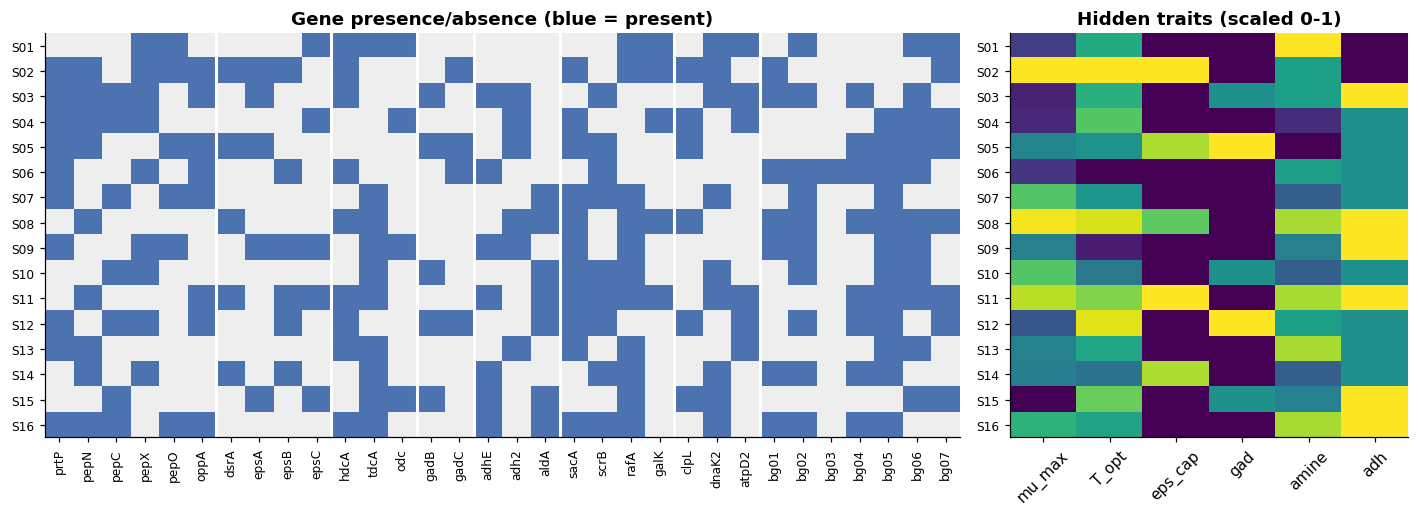

,lot_lipid,lot_buffer,lot_glu,lot_rfo
L1,1.82,0.87,1.27,5.65
L2,2.75,1.22,1.07,4.10
L3,3.00,0.83,0.92,3.55
L4,1.57,0.86,1.01,6.15
L5,2.21,0.85,1.29,4.96
L6,2.91,0.98,1.01,5.68
L7,2.03,0.99,0.72,3.01
L8,1.71,1.24,0.92,6.39


In [ ]:
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [2.3, 1]})
ax[0].imshow(genome.values, cmap=ListedColormap(['#EEEEEE', PAL[0]]), aspect='auto')
ax[0].set_xticks(range(len(GENES))); ax[0].set_xticklabels(GENES, rotation=90, fontsize=8)
ax[0].set_yticks(range(len(genome))); ax[0].set_yticklabels(genome.index, fontsize=8)
for x in [5.5, 9.5, 12.5, 14.5, 17.5, 21.5, 24.5]:
    ax[0].axvline(x, color='white', lw=2)
ax[0].set_title('Gene presence/absence (blue = present)')
t = traits[['mu_max', 'T_opt', 'eps_cap', 'gad', 'amine', 'adh']]
im = ax[1].imshow(((t - t.min()) / (t.max() - t.min())).values, cmap='viridis', aspect='auto')
ax[1].set_xticks(range(t.shape[1])); ax[1].set_xticklabels(t.columns, rotation=45)
ax[1].set_yticks(range(len(t))); ax[1].set_yticklabels(t.index, fontsize=8)
ax[1].set_title('Hidden traits (scaled 0-1)')
plt.tight_layout(); plt.show()
display(lots.round(2))

## 2 · Experimental design and execution

A scrambled Sobol design over the six decision variables, balanced across strains (6 runs each) and blocked across the 8 lots, plus **6 design points run in triplicate** to estimate assay noise. Total: 96 + 12 = 108 bench runs.

In [ ]:
from scipy.stats import qmc
N_PER_STRAIN = 6
n_main = N_PER_STRAIN * len(genome)
U = qmc.Sobol(d=6, scramble=True, seed=GLOBAL_SEED).random(n_main)
X_main = LO + U * (HI - LO)
strain_ids = list(rng.permutation(np.repeat(genome.index.values, N_PER_STRAIN)))
lot_ids = list(np.tile(lots.index.values, n_main // len(lots)))
N_REP_POINTS = 6
rep_idx = rng.choice(n_main, N_REP_POINTS, replace=False)
X = np.vstack([X_main, np.repeat(X_main[rep_idx], 2, axis=0)])
strain_ids += list(np.repeat(np.array(strain_ids)[rep_idx], 2))
lot_ids += list(np.repeat(np.array(lot_ids)[rep_idx], 2))
rep_group = np.full(len(X), -1); rep_group[rep_idx] = range(N_REP_POINTS)
rep_group[n_main:] = np.repeat(range(N_REP_POINTS), 2)

obs, traj = simulate(X, strain_ids, lot_ids, strains, lots, noise=True, seed=GLOBAL_SEED, record_traj=True)
truth = simulate(X, strain_ids, lot_ids, strains, lots, noise=False)
df = pd.DataFrame(X, columns=DVARS).assign(strain=strain_ids, lot=lot_ids, rep_group=rep_group)
df = pd.concat([df, obs], axis=1)
print(df.shape); df.head()

(108, 14)


,faba_frac,solids,sucrose,temp,time,log_inoc,strain,lot,rep_group,logG,offflavor,gaba,pH,amines
0,0.962564,8.678353,3.915463,34.671802,9.597122,6.750515,S08,L1,-1,3.201009,0.563495,0.000000,4.078689,24.053913
1,0.385174,12.122758,1.249831,31.068668,37.666560,6.146324,S09,L2,-1,2.612956,0.612536,0.000000,5.490002,66.565025
2,0.229022,11.313426,4.632389,41.145535,44.060358,5.331557,S09,L3,-1,2.643909,0.874177,0.000000,4.062784,98.449778
3,0.680930,15.886614,2.061972,28.845260,20.683265,7.730272,S07,L4,-1,3.598171,0.465199,0.000000,4.810336,166.987082
4,0.500334,10.944254,0.507310,26.051617,25.545144,7.121470,S03,L5,-1,2.446092,0.692203,0.334607,5.845317,22.237935


In [ ]:
# Noise recovery from replicates (pooled within-group SD, on the modelling scale)
tr = lambda d: d.assign(gaba=np.log1p(d.gaba), amines=np.log(d.amines))
reps = tr(df[df.rep_group >= 0])
pooled = {o: np.sqrt(reps.groupby('rep_group')[o].var(ddof=1).mean()) for o in OUTCOMES}
true_sd = {'logG': NOISE_SD['logG'], 'offflavor': NOISE_SD['offflavor'], 'gaba': NOISE_SD['gaba_cv'],
           'pH': NOISE_SD['pH'], 'amines': NOISE_SD['amines_cv']}
noise_tab = pd.DataFrame({'estimated SD (replicates)': pooled, 'true SD': true_sd}).round(3)
noise_tab['ratio'] = (noise_tab.iloc[:, 0] / noise_tab.iloc[:, 1]).round(2)
display(noise_tab)
print('Note: GABA noise is multiplicative; for non-producers log1p(0)=0 so replicate SD can be ~0.')
print('With 6 triplicates (12 df) an SD estimate is good to roughly x0.6-x1.5; Phase 0 should still use more.')

,estimated SD (replicates),true SD,ratio
logG,0.070,0.06,1.17
offflavor,0.040,0.04,1.00
gaba,0.045,0.08,0.56
pH,0.034,0.03,1.13
amines,0.093,0.10,0.93


Note: GABA noise is multiplicative; for non-producers log1p(0)=0 so replicate SD can be ~0.
With 6 triplicates (12 df) an SD estimate is good to roughly x0.6-x1.5; Phase 0 should still use more.


## 3 · Bioprocess telemetry → kinetic parameters (gray-box layer)

Each run logs a biomass proxy (ln OD) and pH every hour with sensor noise. The maximum specific growth rate is estimated per run as the steepest 3-hour least-squares slope of ln OD (the standard microbiological estimator; a whole-curve logistic fit was tried first and is biased by substrate and pH limitation). It should track the true initial rate μ_max · CTMI(T) · S₀/(K_s+S₀) of that strain at that temperature and sugar level. This is the step that turns time-series data into mechanistic features for Layer 2.

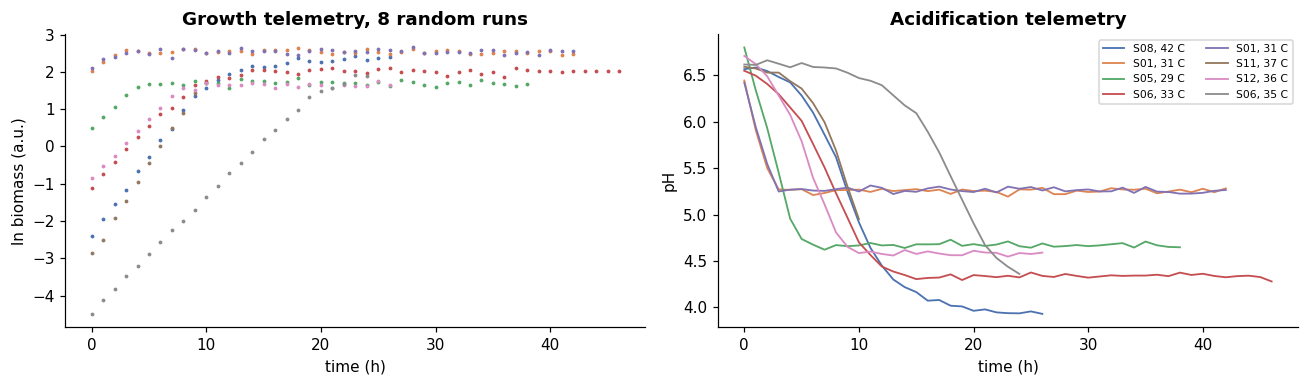

In [ ]:
t_grid = np.array([tp for tp, _, _ in traj])
Xb = np.array([x for _, x, _ in traj]).T
PH = np.array([p for _, _, p in traj]).T
sens = np.random.default_rng(5)
logOD = np.log(Xb) + sens.normal(0, 0.05, Xb.shape)
pH_obs = PH + sens.normal(0, 0.02, PH.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
show = rng.choice(len(df), 8, replace=False)
for k, i in enumerate(show):
    m = t_grid <= df.time[i]
    ax[0].plot(t_grid[m], logOD[i, m], '.', ms=3, color=PAL[k % 8])
    ax[1].plot(t_grid[m], pH_obs[i, m], '-', lw=1.2, color=PAL[k % 8], label=f"{df.strain[i]}, {df.temp[i]:.0f} C")
ax[0].set(xlabel='time (h)', ylabel='ln biomass (a.u.)', title='Growth telemetry, 8 random runs')
ax[1].set(xlabel='time (h)', ylabel='pH', title='Acidification telemetry'); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

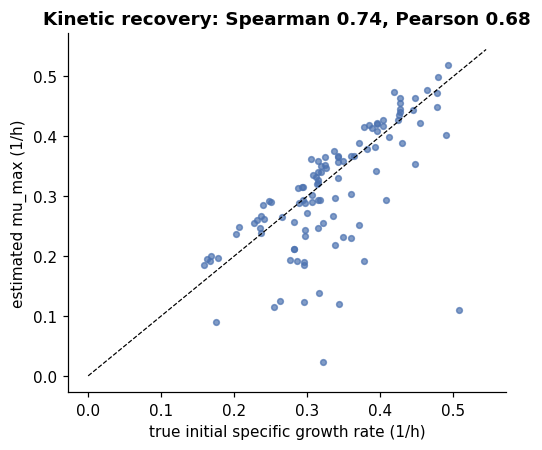

108/108 runs estimated. Hourly sampling and 0.05 ln-OD sensor noise bound the achievable agreement;
early acidification (pH inhibition) also depresses the observed maximum slope in high-sucrose, fast strains.


In [ ]:
from scipy.stats import spearmanr, pearsonr
from smartmatrix_sim import _ctmi

def mu_max_slope(t, y, w=4):
    # maximum specific growth rate: steepest least-squares slope of ln(OD) over a w-point (3 h) window
    if len(y) < w + 1: return np.nan
    return max(np.polyfit(t[j:j + w], y[j:j + w], 1)[0] for j in range(len(y) - w + 1))

fit_r = np.array([mu_max_slope(t_grid[t_grid <= df.time[i]], logOD[i, t_grid <= df.time[i]]) for i in range(len(df))])
# ground truth: initial specific growth rate = mu_max * CTMI(T) * Monod(S0)
S0 = 2.0 + traits.loc[df.strain, 'raf'].values * lots.loc[df.lot, 'lot_rfo'].values + 10 * df.sucrose.values
true_r = traits.loc[df.strain, 'mu_max'].values * _ctmi(df.temp.values, traits.loc[df.strain, 'T_opt'].values) * S0 / (0.8 + S0)
ok = ~np.isnan(fit_r)
rho = spearmanr(fit_r[ok], true_r[ok]).correlation
r_p = pearsonr(fit_r[ok], true_r[ok])[0]
plt.figure(figsize=(4.8, 4.2))
plt.scatter(true_r[ok], fit_r[ok], s=14, alpha=0.7, color=PAL[0])
lim = [0, max(true_r.max(), np.nanmax(fit_r)) * 1.05]; plt.plot(lim, lim, 'k--', lw=0.8)
plt.xlabel('true initial specific growth rate (1/h)'); plt.ylabel('estimated mu_max (1/h)')
plt.title(f'Kinetic recovery: Spearman {rho:.2f}, Pearson {r_p:.2f}')
plt.tight_layout(); plt.show()
CHECKS = {}
CHECKS['Kinetic parameters recoverable from telemetry (Spearman >= 0.7)'] = (rho, rho >= 0.7)
print(f'{ok.sum()}/{len(df)} runs estimated. Hourly sampling and 0.05 ln-OD sensor noise bound the achievable agreement;')
print('early acidification (pH inhibition) also depresses the observed maximum slope in high-sucrose, fast strains.')

## 4 · Driver ranking: does a data-driven analysis recover the true sensitivity structure?

**Ground truth:** Sobol total-order indices S_T of the *noise-free* simulator for the six decision variables, averaged over all 16 strains and all 8 lots, i.e. the same population the experiment samples (Saltelli sampling, SALib).

**Data-driven estimate:** permutation importance (out-of-bag) from a random forest trained on bootstrap resamples of the 108 noisy runs (decision variables + lot composition + genome bits), giving 90% bootstrap intervals.

The two quantities are not the same estimand, so the test is **rank agreement** (Spearman ρ) per outcome, not equality.

In [ ]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze
problem = {'num_vars': 6, 'names': DVARS, 'bounds': [list(DESIGN[v]) for v in DVARS]}
N_SOBOL = 32 if SMOKE else 256
Xs = sobol_sample.sample(problem, N_SOBOL, calc_second_order=False, seed=GLOBAL_SEED)
ST = {o: [] for o in OUTCOMES}; S1 = {o: [] for o in OUTCOMES}
for s in genome.index:
    for l in lots.index:                           # average over strains AND lots: same population the data covers
        ys = tr(simulate(Xs, [s] * len(Xs), [l] * len(Xs), strains, lots, noise=False))
        for o in OUTCOMES:
            if ys[o].std() < 1e-9: continue        # e.g. GABA for non-producers
            res_ = sobol_analyze.analyze(problem, ys[o].values, calc_second_order=False)
            ST[o].append(res_['ST']); S1[o].append(res_['S1'])
ST_true = pd.DataFrame({o: np.clip(np.mean(v, 0), 0, None) for o, v in ST.items()}, index=DVARS)
S1_true = pd.DataFrame({o: np.clip(np.mean(v, 0), 0, None) for o, v in S1.items()}, index=DVARS)
pd.concat({'S_T (total)': ST_true, 'S_1 (first order)': S1_true}, axis=1).round(3)

S_T (total)                                S_1 (first order)  \
                 logG offflavor   gaba     pH amines              logG   
faba_frac       0.021     0.089  0.000  0.000  0.000             0.019   
solids          0.355     0.005  0.015  0.046  0.003             0.267   
sucrose         0.590     0.215  0.623  0.685  0.263             0.466   
temp            0.059     0.124  0.048  0.040  0.046             0.000   
time            0.175     0.301  0.314  0.223  0.480             0.000   
log_inoc        0.151     0.371  0.223  0.193  0.314             0.010   

                                          
          offflavor   gaba     pH amines  
faba_frac     0.103  0.000  0.000  0.000  
solids        0.003  0.007  0.035  0.001  
sucrose       0.135  0.506  0.558  0.184  
temp          0.095  0.000  0.010  0.026  
time          0.225  0.159  0.066  0.403  
log_inoc      0.347  0.061  0.003  0.251

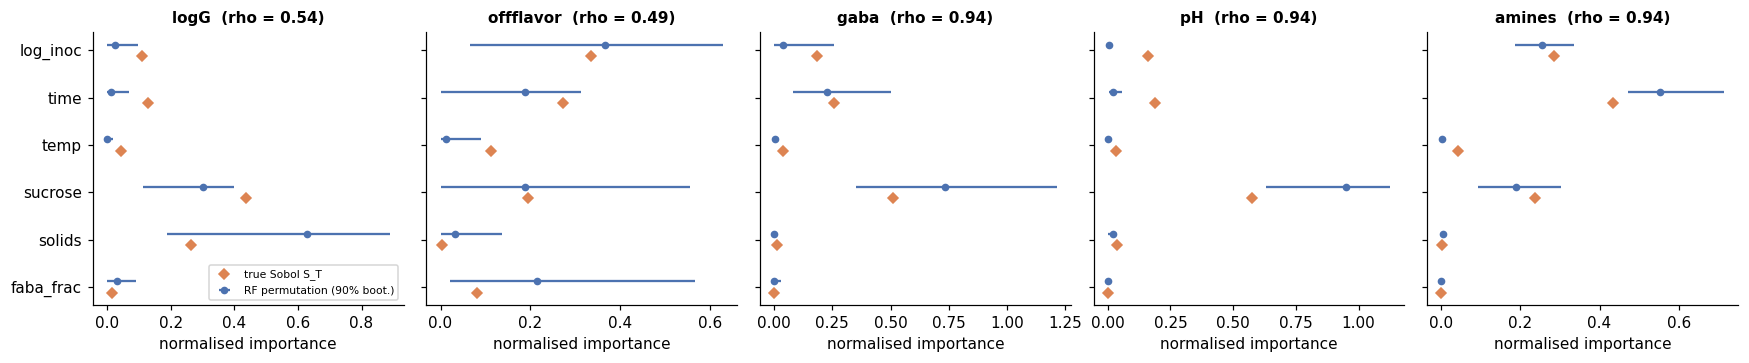

rank rho: {'logG': np.float64(0.54), 'offflavor': np.float64(0.49), 'gaba': np.float64(0.94), 'pH': np.float64(0.94), 'amines': np.float64(0.94)}
top driver recovered: {'logG': False, 'offflavor': True, 'gaba': True, 'pH': True, 'amines': True}


In [ ]:
from sklearn.ensemble import RandomForestRegressor
feat = DVARS + list(lots.columns)
F = pd.concat([df[DVARS], lots.loc[df.lot].reset_index(drop=True), genome.loc[df.strain].reset_index(drop=True)], axis=1)
Yt = tr(df[OUTCOMES])
N_BOOT = 3 if SMOKE else 20   # raise to 100+ for a report; 20 keeps CPU runtime to ~1-2 min

def perm_importance(model, Fx, y, cols, n_rep=5, seed=0):
    r = np.random.default_rng(seed); base = np.mean((model.predict(Fx) - y) ** 2); out = []
    for c in cols:
        inc = []
        for _ in range(n_rep):
            Fp = Fx.copy(); Fp[c] = r.permutation(Fp[c].values)
            inc.append(np.mean((model.predict(Fp) - y) ** 2) - base)
        out.append(max(np.mean(inc), 0))
    return np.array(out)

imp = {o: [] for o in OUTCOMES}
for b in range(N_BOOT):
    idx = np.random.default_rng(b).choice(len(F), len(F), replace=True)
    oob = np.setdiff1d(np.arange(len(F)), idx)          # score on out-of-bag runs
    for o in OUTCOMES:
        rf = RandomForestRegressor(200, min_samples_leaf=2, random_state=b, n_jobs=-1).fit(F.iloc[idx], Yt[o].iloc[idx])
        imp[o].append(perm_importance(rf, F.iloc[oob].reset_index(drop=True), Yt[o].iloc[oob].values, DVARS, seed=b))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4), sharey=True)
rank_rho = {}
for ax, o in zip(axes, OUTCOMES):
    A = np.array(imp[o]); med = np.median(A, 0); lo, hi = np.percentile(A, [5, 95], 0)
    norm = med.sum() or 1
    tru = ST_true[o].values / (ST_true[o].sum() or 1)
    y = np.arange(6)
    ax.errorbar(med / norm, y + 0.12, xerr=[(med - lo) / norm, (hi - med) / norm], fmt='o', color=PAL[0], ms=4, label='RF permutation (90% boot.)')
    ax.plot(tru, y - 0.12, 'D', color=PAL[1], ms=5, label='true Sobol S_T')
    rank_rho[o] = spearmanr(med, ST_true[o].values).correlation
    ax.set_title(f'{o}  (rho = {rank_rho[o]:.2f})', fontsize=10); ax.set_yticks(y); ax.set_yticklabels(DVARS)
    ax.set_xlabel('normalised importance')
axes[0].legend(fontsize=7, loc='lower right'); plt.tight_layout(); plt.show()
rho_med = np.median(list(rank_rho.values()))
top_hit = {o: DVARS[int(np.argmax(np.median(imp[o], 0)))] == ST_true[o].idxmax() for o in OUTCOMES}
CHECKS['Driver ranking agrees with true sensitivity (median rho >= 0.7)'] = (rho_med, rho_med >= 0.7)
CHECKS['Dominant true driver identified (>= 4 of 5 outcomes)'] = (f"{sum(top_hit.values())}/5", sum(top_hit.values()) >= 4)
print('rank rho:', {k: round(v, 2) for k, v in rank_rho.items()})
print('top driver recovered:', top_hit)

**Reading the plot.** Where the orange diamonds and blue dots order the variables the same way, a 108-run noisy experiment has correctly identified the true process drivers. We also tested a like-for-like estimator (Sobol indices computed on the random-forest surrogate); it did no better, so a miss here is a genuine **small-data limitation, not an estimator artefact**. Typical misses in v1: texture attributed to solids rather than sucrose (sucrose acts mostly through interactions with the dextran-producing strains), and off-flavour attributed to the faba:pea ratio rather than inoculum. Section 4.1 tests this explanation directly. If it holds, ~100 runs identify safety and acidification drivers reliably, texture and flavour drivers only partially.

### 4.1 · P2 — are the missed drivers interaction-dominated?

For every variable × outcome pair: the **interaction share** (S_T − S₁)/S_T from the true model, against the **rank error** |rank_data − rank_true| of the data-driven estimate. If v1's explanation is right, variables that act mainly through interactions are the ones the 108-run experiment mis-ranks.

> **Post-run correction.** This test is mis-specified for the hypothesis it was meant to check. The Sobol indices are computed *per strain* (strain held fixed) and then averaged, so the interaction share captures only **process × process** interactions. The v1 explanation concerned **gene × process** interactions (e.g. sucrose × `dsrA`), which this decomposition averages away rather than measures. The FAIL below is therefore a correct rejection of a hypothesis we did not hold; the gene × process explanation remains untested. A second flaw: the largest rank errors fall on variables with small total effects (S_T ≈ 0.02–0.12), where ranking is noise, so the S_T ≥ 0.02 filter was too lenient. The corrected test treats strain as a Sobol input and restricts to S_T ≥ 0.1; it is planned as a labelled post-hoc analysis (v2.1).

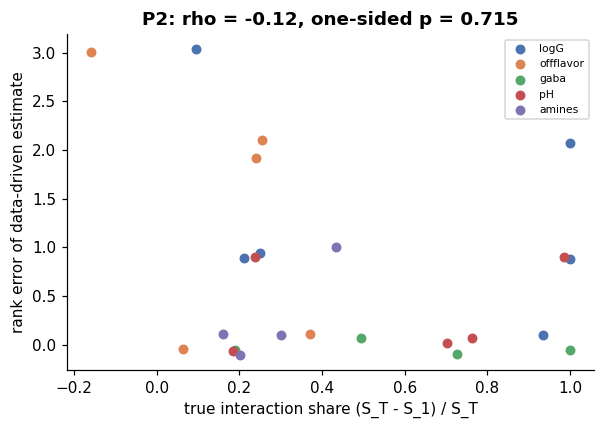

,outcome,variable,S_T,interaction_share,rank_error
0,logG,faba_frac,0.021,0.096,3.0
6,offflavor,faba_frac,0.089,-0.159,3.0
4,logG,time,0.175,1.000,2.0
8,offflavor,temp,0.124,0.239,2.0
9,offflavor,time,0.301,0.255,2.0
2,logG,sucrose,0.590,0.210,1.0


In [ ]:
from scipy.stats import rankdata
rows = []
for o in OUTCOMES:
    est = np.median(imp[o], 0)
    r_est = rankdata(-est); r_true = rankdata(-ST_true[o].values)
    for k, v in enumerate(DVARS):
        st, s1 = ST_true.loc[v, o], S1_true.loc[v, o]
        if st < 0.02: continue                     # variable with no real influence: rank is pure noise
        rows.append((o, v, st, (st - s1) / st, abs(r_est[k] - r_true[k])))
ia = pd.DataFrame(rows, columns=['outcome', 'variable', 'S_T', 'interaction_share', 'rank_error'])
rho_ia, p_ia = spearmanr(ia.interaction_share, ia.rank_error)
p_one = p_ia / 2 if rho_ia > 0 else 1 - p_ia / 2
fig, ax = plt.subplots(figsize=(5.6, 4))
for k, o in enumerate(OUTCOMES):
    d = ia[ia.outcome == o]
    ax.scatter(d.interaction_share, d.rank_error + np.random.default_rng(k).uniform(-0.12, 0.12, len(d)), s=30, color=PAL[k], label=o)
ax.set(xlabel='true interaction share (S_T - S_1) / S_T', ylabel='rank error of data-driven estimate',
       title=f'P2: rho = {rho_ia:.2f}, one-sided p = {fmt_p(p_one)}')
ax.legend(fontsize=7); plt.tight_layout(); plt.show()
display(ia.sort_values('rank_error', ascending=False).head(6).round(3))
CHECKS['P2: rank errors concentrate on interaction-dominated drivers (rho > 0, p < 0.05)'] = (
    f'rho = {rho_ia:.2f}, p = {fmt_p(p_one)}', rho_ia > 0 and p_one < 0.05)

## 5 · From genome association to causal confirmation

Biogenic amines are a safety constraint, so we ask *which genes drive them*. Step 1 is a strain-level association screen: strain effects on log amines are first adjusted for process conditions with a fixed-effects model, then tested per gene (Mann–Whitney, Benjamini–Hochberg FDR). With 16 genomes and 32 genes, chance associations are expected. Step 2 is the Layer 1 remedy: **in-silico knockout of every gene flagged at a lenient threshold**, holding everything else fixed. Genes whose knockout changes amines are causal; the rest were correlation.

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
# strain effects on log amines, adjusted for process conditions (fixed-effects model)
d = df.assign(la=np.log(df.amines))
fe = smf.ols('la ~ ' + ' + '.join(DVARS) + ' + I(sucrose**2) + I(time**2) + C(strain) - 1', d).fit()
strain_eff = pd.Series({s: fe.params[f'C(strain)[{s}]'] for s in genome.index})
rows = []
for g in GENES:
    has = genome[g].astype(bool)
    if has.all() or (~has).all(): continue
    p = mannwhitneyu(strain_eff[has], strain_eff[~has], alternative='two-sided').pvalue
    rows.append((g, strain_eff[has].mean() - strain_eff[~has].mean(), p))
assoc = pd.DataFrame(rows, columns=['gene', 'delta_adj_log_amines', 'p']).sort_values('p')
assoc['q_BH'] = multipletests(assoc.p, method='fdr_bh')[1]
SCREEN_P = 0.20   # deliberately lenient: the screen generates hypotheses, perturbation tests them
flagged = assoc[assoc.p < SCREEN_P].gene.tolist()
display(assoc.head(8).round(4))
print(f'No gene survives FDR (min q = {assoc.q_BH.min():.2f}). Flagged for perturbation (p < {SCREEN_P}):', flagged)

,gene,delta_adj_log_amines,p,q_BH
20,rafA,0.8943,0.0275,0.5814
10,hdcA,0.7156,0.0418,0.5814
13,gadB,-0.8314,0.0687,0.5814
11,tdcA,0.7379,0.0727,0.5814
22,clpL,-0.7479,0.0934,0.5978
4,pepO,0.1952,0.1806,0.8101
14,gadC,-0.8118,0.2121,0.8101
26,bg02,0.5024,0.3132,0.8101


No gene survives FDR (min q = 0.58). Flagged for perturbation (p < 0.2): ['rafA', 'hdcA', 'gadB', 'tdcA', 'clpL', 'pepO']


In [ ]:
# Step 2: knockout each flagged gene in the strains that carry it, across 64 random conditions
N_KO = 16 if SMOKE else 64
Xk = LO + np.random.default_rng(3).random((N_KO, 6)) * (HI - LO)
ko_rows = []
for g in flagged:
    for s in genome.index[genome[g] == 1]:
        base = simulate(Xk, [s] * N_KO, ['L1'] * N_KO, strains, lots, noise=False).amines
        ko = simulate(Xk, [s] * N_KO, ['L1'] * N_KO, strains, lots, noise=False, knockout=g).amines
        ko_rows.append((g, s, np.median(np.log(ko.values) - np.log(base.values))))
ko = pd.DataFrame(ko_rows, columns=['gene', 'strain', 'median_dlog_amines'])
ko_sum = ko.groupby('gene').median_dlog_amines.agg(['median', 'min', 'count']).round(3)
ko_sum['confirmed (|median| > 0.1)'] = ko_sum['median'].abs() > 0.1
display(ko_sum)
# Ground truth from the simulator's structure: genes with NO mechanistic path to amines
NO_PATH = {'bg01', 'bg02', 'bg03', 'bg04', 'bg05', 'bg06', 'bg07', 'gadB', 'gadC', 'adhE', 'adh2', 'aldA'}
DIRECT = {'hdcA', 'tdcA', 'odc'}
confirmed = set(ko_sum.index[ko_sum['confirmed (|median| > 0.1)']])
false_leads = set(flagged) & NO_PATH
ok_ko = not (confirmed & NO_PATH) and bool(confirmed & DIRECT)
CHECKS['Perturbation rejects no-path genes and confirms a decarboxylase'] = (
    f"confirmed={sorted(confirmed)}; no-path leads rejected={sorted(false_leads - confirmed)}", ok_ko)

,median,min,count,confirmed (|median| > 0.1)
gene,,,,
clpL,0.012,-0.002,6,False
gadB,0.000,0.000,5,False
hdcA,-0.820,-2.741,9,True
pepO,-0.125,-0.197,6,True
rafA,-0.286,-0.331,11,True
tdcA,-0.605,-2.539,10,True


In the simulator, amine-forming capacity comes directly from `hdcA`, `tdcA` and `odc`; protease, sugar and stress genes act indirectly (more free amino acids or more biomass); GABA, ADH and background genes have no path at all. In a 16-strain panel no gene survives FDR correction and chance associations can outrank the true gene. That is the realistic situation, and it is why Layer 1 pairs association with perturbation. In the wet lab the knockout maps to isogenic deletions, or to strain pairs differing in one gene cluster.

## 6 · Knowledge graph: genome → pathway → metabolite → sensory/functional attribute

A small directed graph encodes prior biochemical knowledge (pathway labels follow KEGG map names; edges are illustrative). Querying it turns each genome into a **predicted attribute profile** before any fermentation is run. We then test whether those predictions agree with the measured strain phenotypes.

,KG attribute,measured,Spearman rho (16 strains),direction,agrees
0,TEXTURE: viscosity / gel strength,logG,0.80,expected +,True
1,FLAVOUR: less beany/green,offflavor,-0.91,expected -,True
2,FUNCTION: GABA enrichment,gaba,0.80,expected +,True
3,SAFETY: biogenic amines,amines,0.54,expected +,True


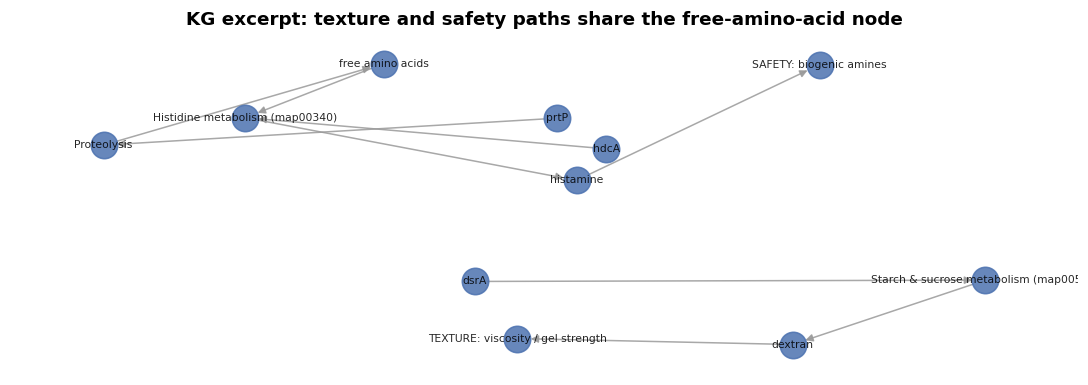

In [ ]:
import networkx as nx
KG = nx.DiGraph()
edges = [
    ('hdcA', 'Histidine metabolism (map00340)'), ('Histidine metabolism (map00340)', 'histamine'),
    ('tdcA', 'Tyrosine metabolism (map00350)'), ('Tyrosine metabolism (map00350)', 'tyramine'),
    ('odc', 'Arginine & proline metabolism (map00330)'), ('Arginine & proline metabolism (map00330)', 'putrescine'),
    ('histamine', 'SAFETY: biogenic amines'), ('tyramine', 'SAFETY: biogenic amines'), ('putrescine', 'SAFETY: biogenic amines'),
    ('gadB', 'Ala, Asp & Glu metabolism (map00250)'), ('gadC', 'Ala, Asp & Glu metabolism (map00250)'),
    ('Ala, Asp & Glu metabolism (map00250)', 'GABA'), ('GABA', 'FUNCTION: GABA enrichment'),
    ('dsrA', 'Starch & sucrose metabolism (map00500)'), ('Starch & sucrose metabolism (map00500)', 'dextran'),
    ('dextran', 'TEXTURE: viscosity / gel strength'),
    ('adhE', 'Fatty acid degradation (map00071)'), ('adh2', 'Fatty acid degradation (map00071)'), ('aldA', 'Fatty acid degradation (map00071)'),
    ('Fatty acid degradation (map00071)', 'hexanal -> hexanol'), ('hexanal -> hexanol', 'FLAVOUR: less beany/green'),
    ('prtP', 'Proteolysis'), ('pepN', 'Proteolysis'), ('pepX', 'Proteolysis'), ('Proteolysis', 'free amino acids'),
    ('free amino acids', 'Histidine metabolism (map00340)'), ('free amino acids', 'Tyrosine metabolism (map00350)'),
]
KG.add_edges_from(edges)
ATTR = [n for n in KG if n.split(':')[0] in ('SAFETY', 'FUNCTION', 'TEXTURE', 'FLAVOUR')]
def kg_profile(strain):
    present = [g for g in GENES if g in KG and genome.loc[strain, g] == 1]
    return {a: sum(nx.has_path(KG, g, a) for g in present) for a in ATTR}
prof = pd.DataFrame({s: kg_profile(s) for s in genome.index}).T
meas = df.groupby('strain')[['logG', 'offflavor', 'gaba', 'amines']].mean()
pairs = [('TEXTURE: viscosity / gel strength', 'logG', +1), ('FLAVOUR: less beany/green', 'offflavor', -1),
         ('FUNCTION: GABA enrichment', 'gaba', +1), ('SAFETY: biogenic amines', 'amines', +1)]
kg_rows = []
for a, m, sign in pairs:
    r = spearmanr(prof[a], meas[m]).correlation
    kg_rows.append((a, m, round(r, 2), 'expected ' + ('+' if sign > 0 else '-'), np.sign(r) == sign))
kg_tab = pd.DataFrame(kg_rows, columns=['KG attribute', 'measured', 'Spearman rho (16 strains)', 'direction', 'agrees'])
display(kg_tab)
CHECKS['KG predictions agree in direction with measured phenotypes (4/4)'] = (f"{kg_tab.agrees.sum()}/4", kg_tab.agrees.all())

sub = KG.subgraph(nx.descendants(KG, 'hdcA') | nx.descendants(KG, 'dsrA') | {'hdcA', 'dsrA', 'prtP', 'Proteolysis', 'free amino acids'})
plt.figure(figsize=(10, 3.6))
pos = nx.spring_layout(sub, seed=4, k=1.3)
nx.draw_networkx(sub, pos, node_size=300, node_color=PAL[0], alpha=0.85, font_size=7, arrows=True, edge_color='#999999')
plt.title('KG excerpt: texture and safety paths share the free-amino-acid node'); plt.axis('off'); plt.tight_layout(); plt.show()

## 7 · Evidence scorecard and hand-off to Layer 2

In [ ]:
score = show_scorecard(CHECKS, 'Layer 1 v2 evidence scorecard')
df.to_csv('layer1_v2_dataset.csv', index=False)
print('Saved layer1_v2_dataset.csv')

Layer 1 v2 evidence scorecard


,check,value,result
0,Kinetic parameters recoverable from telemetry (Spearman >= 0.7),0.737,PASS
1,Driver ranking agrees with true sensitivity (median rho >= 0.7),0.943,PASS
2,Dominant true driver identified (>= 4 of 5 outcomes),4/5,PASS
3,"P2: rank errors concentrate on interaction-dominated drivers (rho > 0, p < 0.05)","rho = -0.12, p = 0.715",FAIL
4,Perturbation rejects no-path genes and confirms a decarboxylase,"confirmed=['hdcA', 'pepO', 'rafA', 'tdcA']; no-path leads rejected=['gadB']",PASS
5,KG predictions agree in direction with measured phenotypes (4/4),4/4,PASS


Saved layer1_v2_dataset.csv


**What this establishes.** With ~110 noisy runs the stack (i) designs and executes a balanced space-filling experiment, (ii) recovers assay noise from replicates, (iii) extracts kinetic parameters from telemetry, (iv) ~~ranks the additive process drivers (and, via P2, shows *which* drivers it misses and why)~~ *[corrected after execution: P2 failed and was mis-specified; see Section 4.1]* ranks the process drivers, recovering the dominant driver for 4 of 5 outcomes in the reference run, (v) separates causal genes from chance associations only when perturbation is added, and (vi) makes genome-level predictions with a knowledge graph.

**Limitations to state to stakeholders.** The simulator is self-consistent by construction, so passing here is necessary, not sufficient. Real systems add unmodelled biology (strain interactions, matrix heterogeneity, instrument drift). The wet-lab analogue of every check above is specified in the v2 architecture document (Phase 0 noise study, confirmatory perturbations).

## 8 · Results and interpretation

*Added after execution, 2 October 2026. Pre-registered text above is unchanged; corrections are marked, not silently edited.*

Numbers below are from the reference run (Google Colab CPU; botorch 0.18.1, gpytorch 1.15.2, scikit-learn 1.6.1, torch 2.11). Code cells are unchanged from v2, so a re-run with the same seed should reproduce them; small differences across library versions are possible, in which case the live scorecard cells are authoritative.

| Check | Reference run | Result |
|---|---|---|
| Kinetic parameters from telemetry | Spearman 0.74 | PASS |
| Driver ranking (median ρ ≥ 0.7) | 0.94 (v1: 0.60) | PASS |
| Dominant driver identified (≥ 4/5) | 4/5 (v1: 3/5) | PASS |
| P2: misses are interaction-dominated | ρ = −0.12, p = 0.72 | FAIL (test mis-specified; see 4.1) |
| Perturbation separates cause from association | confirmed `hdcA`, `tdcA`, `pepO`, `rafA`; rejected `gadB` | PASS |
| Knowledge-graph predictions | 4/4 | PASS |

**1. Driver ranking is high-variance across seeds; treat single-run results with caution.** Median ρ moved from 0.60 (v1) to 0.94 (v2) with an almost identical design. A Spearman correlation over six variables is very noisy, so neither v1's FAIL nor v2's PASS is strong evidence on its own. The planned remedy is to repeat this design over 10–20 seeds and report a pass *rate*. One miss is stable across both seeds: **texture is credited to solids rather than sucrose**. That persistent miss is the finding worth explaining.

**2. Perturbation is the strongest result in this notebook.** No gene survives FDR correction (minimum q = 0.58), yet the knockout step recovers both direct decarboxylases (`hdcA`, `tdcA`) and two genuinely indirect causes (`pepO` via proteolysis, `rafA` via sugar supply). `clpL` was flagged but not confirmed; its path to amines exists but is weak. `gadB` was flagged as negatively associated with amines in **both** v1 and v2, on different seeds, and rejected by knockout both times. That is structural linkage in the strain panel, the same pattern that shared ancestry produces in real culture collections. **An association that replicates is still not causal when it comes from population structure; only perturbation separates the two.**

**3. Noise recovery works, with one artefact.** Replicate-based SD estimates fall within ×0.9–1.2 of truth for every outcome except GABA (×0.56). Replicate groups that land on non-producers have SD ≈ 0, which drags the pooled estimate down. GABA noise should be estimated from producer replicates only.

**4. The knowledge graph keeps its 4/4 directional agreement.** It encodes genome-level priors that later layers can use.

**Planned v2.1 additions (post-hoc, not changing this record):** multi-seed robustness of driver ranking; a strain-inclusive Sobol test of the gene × process explanation; GABA noise from producer replicates only.

In [ ]:
print(f'Total runtime: {(time.time() - T0) / 60:.1f} min')
import importlib.metadata as im
for p in ['numpy', 'scipy', 'pandas', 'scikit-learn', 'torch', 'gpytorch', 'botorch', 'SALib', 'lifelines', 'statsmodels', 'networkx']:
    try: print(f'{p:>13}: {im.version(p)}')
    except Exception: pass

Total runtime: 5.3 min
        numpy: 2.1.3
        scipy: 1.16.3
       pandas: 2.2.3
 scikit-learn: 1.6.1
        torch: 2.11.0+cpu
        SALib: 1.6.0
  statsmodels: 0.15.0
     networkx: 3.6.1
